<a href="https://colab.research.google.com/github/jooharver/Machine-Learning/blob/main/ML_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Eka Krisna Ferian
Kelas : TI-3D
NIM : 2241720100

**Job Sheet 9: Perceptron dan ANN**

**Praktikum 1**

Klasifikasi Iris dengan Perceptron

In [2]:
#Import Library

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


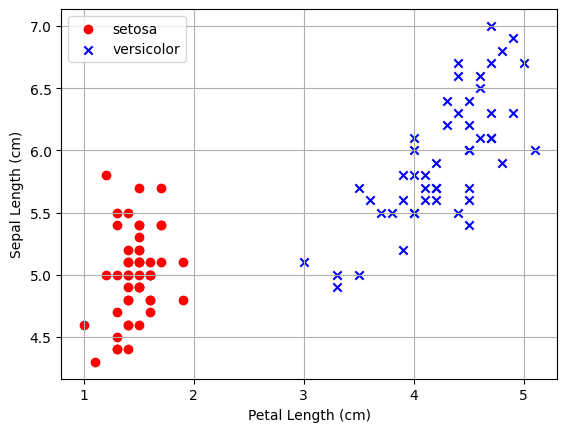

In [28]:
# Load dataset dengan header
df = pd.read_csv('/content/drive/My Drive/ML/iris.csv', header=0)

# Pisahkan data berdasarkan spesies
setosa = df[df['Species'] == 'Iris-setosa']
versicolor = df[df['Species'] == 'Iris-versicolor']

# Pilih kolom PetalLengthCm dan SepalLengthCm untuk plotting
plt.scatter(setosa['PetalLengthCm'], setosa['SepalLengthCm'], color='red', marker='o', label='setosa')
plt.scatter(versicolor['PetalLengthCm'], versicolor['SepalLengthCm'], color='blue', marker='x', label='versicolor')

# Menambahkan label dan legenda
plt.xlabel('Petal Length (cm)')
plt.ylabel('Sepal Length (cm)')
plt.legend(loc='upper left')
plt.grid()
plt.show()


In [30]:
# Membuat kelas Perceptron
class Perceptron(object):
    def __init__(self, eta=0.01, n_iter=10):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w_ = np.zeros(1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[0] += update
                self.w_[1:] += update * xi
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)


In [33]:
#Pilih data dan encoding label

y = df.iloc[0:100, 4].values # pilih 100 data awal
y = np.where(y == 'Iris-setosa', -1, 1) # ganti coding label

# Extract the desired columns by their names
# Assuming '0' corresponds to 'SepalLengthCm' and '3' to 'PetalWidthCm'
X = df.iloc[0:100, [0, 3]].values

# Convert the selected columns to numeric
X = X.astype(np.float64)

In [34]:
#Fitting label

ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)

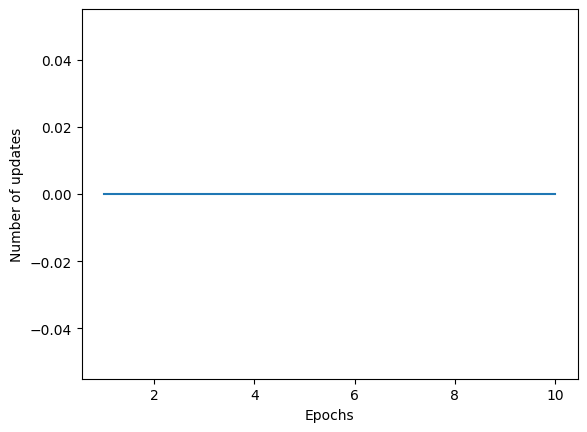

In [35]:
#Visualisasi nilai error per epoch

plt.plot(range(1, len(ppn.errors_)+1), ppn.errors_)
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.show()

<ipython-input-41-ae38a2575f55>:33: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[y == cl, 0], X[y == cl, 1], alpha=0.8,


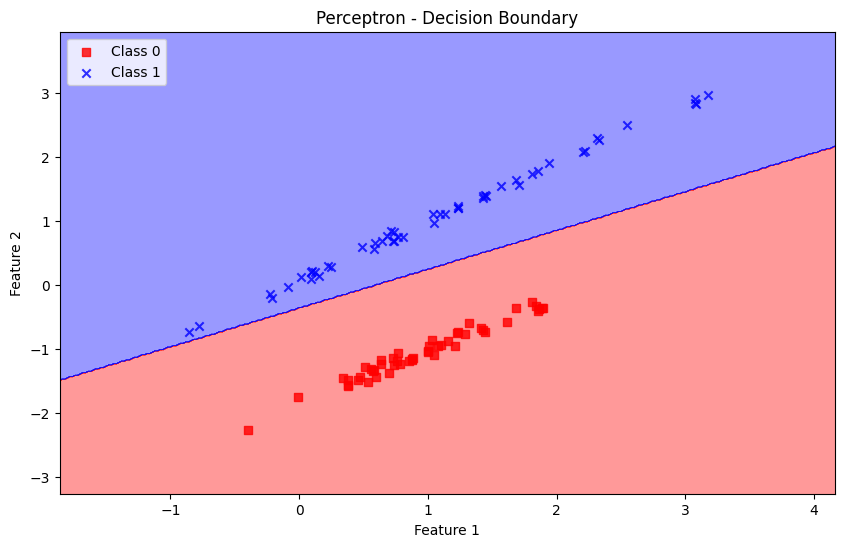

In [41]:
#Visualisasi Decision Boundary


X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Melatih model Perceptron
classifier = Perceptron()
classifier.fit(X, y)

def plot_decision_regions(X, y, classifier, resolution=0.02):
    # Setup marker generator and color map
    markers = ('s', 'x')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors)

    # Plot the decision regions
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))

    # Predict class labels for grid points
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    # Draw the contour
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot class samples
    for i, cl in enumerate(np.unique(y)):
        plt.scatter(X[y == cl, 0], X[y == cl, 1], alpha=0.8,
                    c=cmap(i), marker=markers[i], label=f'Class {cl}')

# Panggil fungsi untuk memplot
plt.figure(figsize=(10, 6))
plot_decision_regions(X, y, classifier)
plt.title('Perceptron - Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')
plt.show()


**Praktikum 2**

Klasifikasi Berita dengan Perceptron

In [42]:
#Import Library

from sklearn.datasets import fetch_20newsgroups # download dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Perceptron
from sklearn.metrics import f1_score, classification_report

In [43]:
#Pilih label dan split data

categories = ['rec.sport.hockey', 'rec.sport.baseball', 'rec.autos']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

In [44]:
#Ekstrak fitur dan buat model perceptron

# Ekstrak Fitur
vectorizer = TfidfVectorizer()

# Fit fitur
X_train = vectorizer.fit_transform(newsgroups_train.data)
X_test = vectorizer.transform(newsgroups_test.data)

# Fit Model
clf = Perceptron(random_state=11)
clf.fit(X_train, newsgroups_train.target)

# Prediksi
predictions = clf.predict(X_test)
print(classification_report(newsgroups_test.target, predictions))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       396
           1       0.82      0.83      0.83       397
           2       0.88      0.87      0.87       399

    accuracy                           0.86      1192
   macro avg       0.86      0.86      0.86      1192
weighted avg       0.86      0.86      0.86      1192



**Praktikum 3**

Nilai Logika XOR dengan MLP

In [45]:
#Import library

from sklearn.neural_network import MLPClassifier

In [46]:
#Buat data

y = [0, 1, 1, 0] # label
X = [[0, 0], [0, 1], [1, 0], [1, 1]] # data

In [47]:
# Fit model

clf = MLPClassifier(solver='lbfgs', activation='logistic', hidden_layer_sizes=(2,), max_iter=100, random_state=20)
clf.fit(X, y)

MLPClassifier(activation='logistic', hidden_layer_sizes=(2,), max_iter=100,
              random_state=20, solver='lbfgs')

In [48]:
#Prediksi

pred = clf.predict(X)
print('Accuracy: %s' % clf.score(X, y))
for i,p in enumerate(pred[:10]):
    print('True: %s, Predicted: %s' % (y[i], p))

Accuracy: 1.0
True: 0, Predicted: 0
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 0, Predicted: 0


**Praktikum 4**

Klasifikasi dengan ANN

In [49]:
#Import Library

import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

In [51]:
#Load data

dataset = pd.read_csv('/content/drive/My Drive/ML/Churn_Modelling.csv')
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [52]:
#Cek data
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [54]:
#Encoding data kategorikal

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

#Cek data
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [56]:
#Encoding kolom "Geography" dengan One Hot Encoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

#Cek data
print(X)

[[1.0 0.0 1.0 ... 1 1 101348.88]
 [1.0 0.0 0.0 ... 0 1 112542.58]
 [1.0 0.0 1.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 1.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 1.0 ... 1 0 38190.78]]


In [57]:
#Split Data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [58]:
#Scaling fitur

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Membuat Model ANN

In [59]:
#Inisialisasi model ANN

ann = tf.keras.models.Sequential()

In [60]:
#Membuat input layer dan Hidden layer pertama

ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [61]:
#Membuat output layer

ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

Training Model

In [62]:
#Compile model (menyatukan arsitektur) ANN

ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [63]:
#Fitting model

ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7873 - loss: 0.6455
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8002 - loss: 0.5165
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8026 - loss: 0.4617
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8121 - loss: 0.4340
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8066 - loss: 0.4312
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8302 - loss: 0.4049
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8208 - loss: 0.4181
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8214 - loss: 0.4054
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8305 - loss: 0.3983
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8173 - loss: 0.4073
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8239 - loss: 0.4003
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

Membuat Prediksi

Diberikan informasi sebagai berikut,

    Geography: France

    Credit Score: 600

    Gender: Male

    Age: 40 years old

    Tenure: 3 years

    Balance: $ 60000

    Number of Products: 2

    Does this customer have a credit card ? Yes

    Is this customer an Active Member: Yes

    Estimated Salary: $ 50000

Apakah customer tersebut perlu dipertahankan?

In [65]:
#Modelkan data baru dan buat prediksi

print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000, 0]])) > 0.5) # Added a '0' as a placeholder for the 13th feature

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[False]]


In [66]:
#Prediksi data dengan testing

y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [67]:
#Cek akurasi Confusion Matrix

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1491  104]
 [ 197  208]]


0.8495